# Import Libraries

In [19]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\elhad/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Load Data

In [3]:
df_ecom = pd.read_csv(r'C:\Users\elhad\Videos\Alaa_Essam_Ai_Discovery_Camp\FinalProject\dataset\E-Commerce_data.csv')
df_saas = pd.read_csv(r'C:\Users\elhad\Videos\Alaa_Essam_Ai_Discovery_Camp\FinalProject\dataset\SaaS_Tech_data.csv')


# Merge title + description

In [4]:
df_ecom['text'] = df_ecom['title'] + ' ' + df_ecom['description']
df_saas['text'] = df_saas['title'] + ' ' + df_saas['description']

df_ecom.drop(['title', 'description'], axis=1, inplace=True)
df_saas.drop(['title', 'description'], axis=1, inplace=True)

# Drop Unnecessary Columns

In [5]:
cols_to_drop = ['ticket_id', 'category', 'industry', 'sentiment',
                'created_date', 'channel', 'resolution_time_hours']

df_ecom.drop(cols_to_drop, axis=1, inplace=True)
df_saas.drop(cols_to_drop, axis=1, inplace=True)

# Encode Target

In [6]:
priority_mapping = {'low': 0, 'medium': 1, 'high': 2}

df_ecom['priority'] = df_ecom['priority'].map(priority_mapping)
df_saas['priority'] = df_saas['priority'].map(priority_mapping)


# Merge DataFrames

In [8]:
df = pd.concat([df_ecom, df_saas], axis=0, ignore_index=True)

In [9]:
df

,priority,text
0,2,"Account suspended without notification Hi,\n\n..."
1,1,"Website logs me out every few minutes Hey,\n\n..."
2,1,Website logs me out every few minutes The site...
3,1,Refund for order ORD-8311097 not received afte...
4,0,Partial refund for order ORD-8529542 is short ...
...,...,...
19994,1,Admin cannot assign custom roles Dear support ...
19995,0,Invited user gets Access Denied after acceptin...
19996,2,Custom domain stuck Unverified after 72 hours ...
19997,2,Still billed for 87 seats after downgrading to...


# Train Test Split

In [10]:
X = df['text']
y = df['priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
    shuffle=True
)

# Custom Cleaning Function

In [11]:
def clean_text_list(texts):
    stop_words = set(stopwords.words('english'))
    cleaned = []

    for text in texts:
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'\d+', '', text)
        text = text.lower()
        text = ' '.join([w for w in text.split() if w not in stop_words])
        text = re.sub(r'[^a-z\s]', '', text)
        text = ' '.join(text.split())
        cleaned.append(text)

    return cleaned

cleaner = FunctionTransformer(clean_text_list, validate=False)

# Pipeline - Logistic Regression

In [12]:
pipeline_lr = Pipeline([
    ("cleaning", cleaner),
    ("tfidf", TfidfVectorizer(
        max_features=7000,
        ngram_range=(1,2),
        min_df=3
    )),
    ("model", LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=1000
    ))
])

In [35]:
pipeline_lr.fit(X_train, y_train)

y_pred_lr = pipeline_lr.predict(X_test)

print("====== Logistic Regression ======")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("================================")
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n", cm_lr)

====== Logistic Regression ======
              precision    recall  f1-score   support

           0       0.19      0.20      0.20       591
           1       0.61      0.47      0.53      1466
           2       0.69      0.80      0.74      1943

    accuracy                           0.59      4000
   macro avg       0.50      0.49      0.49      4000
weighted avg       0.59      0.59      0.58      4000

Accuracy: 0.5885
Confusion Matrix:
 [[ 119  224  248]
 [ 330  687  449]
 [ 173  222 1548]]


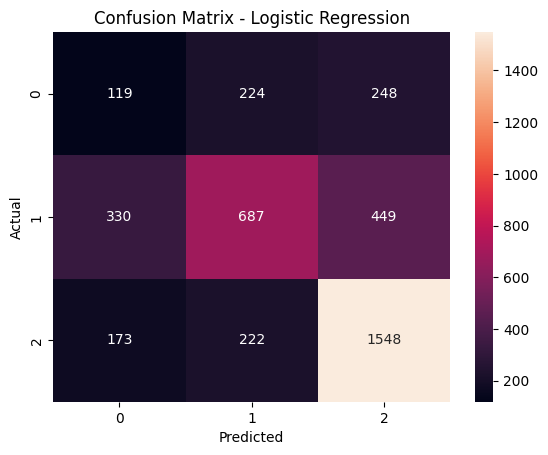

In [36]:
plt.figure()
sns.heatmap(cm_lr, annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Pipeline - Random Forest

In [16]:
pipeline_rf = Pipeline([
    ("cleaning", cleaner),
    ("tfidf", TfidfVectorizer(
        max_features=7000,
        ngram_range=(1,2),
        min_df=3
    )),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

In [37]:
pipeline_rf.fit(X_train, y_train)

y_pred_rf = pipeline_rf.predict(X_test)

print("====== Random Forest ======")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("================================")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf)

====== Random Forest ======
              precision    recall  f1-score   support

           0       0.17      0.16      0.17       591
           1       0.54      0.51      0.53      1466
           2       0.66      0.70      0.68      1943

    accuracy                           0.55      4000
   macro avg       0.46      0.46      0.46      4000
weighted avg       0.54      0.55      0.55      4000

Accuracy: 0.5505
Confusion Matrix:
 [[  95  245  251]
 [ 257  747  462]
 [ 204  379 1360]]


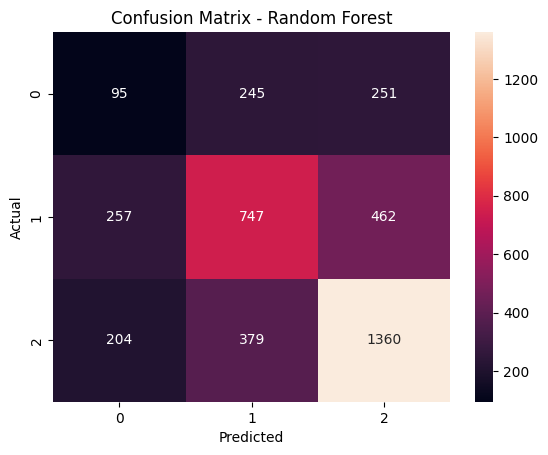

In [38]:
plt.figure()
sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Pipeline - Linear SVM

In [21]:
pipeline_LSVM = Pipeline([
        ("cleaning", cleaner),
        ("tfidf", TfidfVectorizer(
            max_features=7000, 
            ngram_range=(1,2), 
            min_df=3)),
        ("model", LinearSVC(
            class_weight="balanced",
            max_iter=10000, 
            random_state=42))
    ])

In [39]:
pipeline_LSVM.fit(X_train, y_train)

y_pred_LSVM = pipeline_LSVM.predict(X_test)

print("====== Linear SVM ======")
print(classification_report(y_test, y_pred_LSVM))
print("Accuracy:", accuracy_score(y_test, y_pred_LSVM))
print("================================")
cm_LSVM = confusion_matrix(y_test, y_pred_LSVM)
print("Confusion Matrix:\n", cm_LSVM)

====== Linear SVM ======
              precision    recall  f1-score   support

           0       0.21      0.13      0.16       591
           1       0.58      0.56      0.57      1466
           2       0.69      0.78      0.73      1943

    accuracy                           0.60      4000
   macro avg       0.49      0.49      0.49      4000
weighted avg       0.57      0.60      0.59      4000

Accuracy: 0.60175
Confusion Matrix:
 [[  78  272  241]
 [ 201  816  449]
 [ 100  330 1513]]


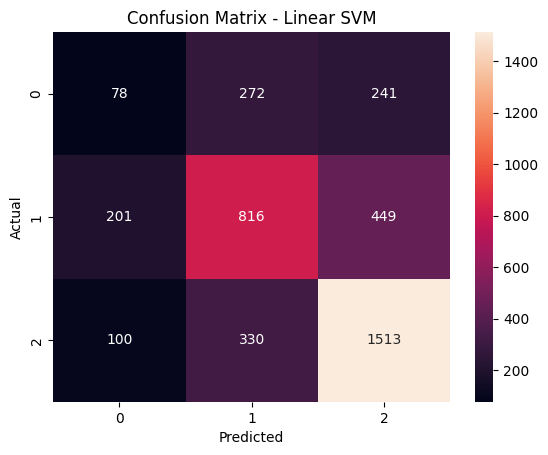

In [40]:
plt.figure()
sns.heatmap(cm_LSVM, annot=True, fmt="d")
plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Pipeline - MNB

In [41]:
counts = y_train.value_counts().sort_index()
total = len(y_train)
class_prior = counts / total
class_prior_list = class_prior.tolist()  # [low, medium, high]

In [32]:
pipeline_MNB = Pipeline([
        ("cleaning", cleaner),
        ("tfidf", TfidfVectorizer(
            max_features=7000, 
            ngram_range=(1,2), 
            min_df=3)),
        ("model", MultinomialNB(class_prior=class_prior_list))
        ])

In [43]:
pipeline_MNB.fit(X_train, y_train)

y_pred_MNB = pipeline_MNB.predict(X_test)

print("====== Multinomial Naive Bayes ======")
print(classification_report(y_test, y_pred_MNB))
print("Accuracy:", accuracy_score(y_test, y_pred_MNB))
print("================================")
cm_MNB = confusion_matrix(y_test, y_pred_MNB)
print("Confusion Matrix:\n", cm_MNB)

====== Multinomial Naive Bayes ======
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       591
           1       0.60      0.68      0.64      1466
           2       0.69      0.83      0.75      1943

    accuracy                           0.65      4000
   macro avg       0.43      0.50      0.46      4000
weighted avg       0.55      0.65      0.60      4000

Accuracy: 0.651
Confusion Matrix:
 [[   0  331  260]
 [   1 1001  464]
 [   1  339 1603]]


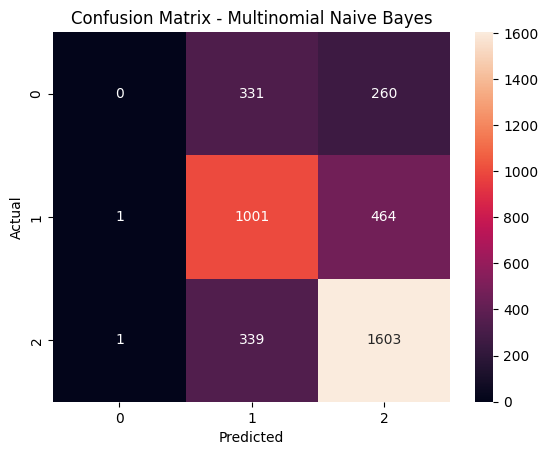

In [42]:
plt.figure()
sns.heatmap(cm_MNB, annot=True, fmt="d")
plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [44]:
from xgboost import XGBClassifier

In [ ]:
class_counts = y_train.value_counts().sort_index()
weights = len(y_train) / (len(class_counts) * class_counts)
sample_weights = y_train.map(weights)

In [51]:
xgb_pipe = Pipeline([
    ("cleaning", cleaner),

    ("tfidf", TfidfVectorizer(
        max_features=50000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
    )),

    ("model", XGBClassifier(
        objective='multi:softmax',
        num_class=3,
        n_estimators=400,      
        max_depth=7,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        eval_metric="mlogloss",
        scale_pos_weight=3
    ))
])

In [ ]:
xgb_pipe.fit(X_train, y_train, model__sample_weight=sample_weights)

c:\Users\elhad\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:10:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('cleaning',
                 FunctionTransformer(func=<function clean_text_list at 0x00000269E01000E0>)),
                ('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=50000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.9, device=None,
                               e...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.08,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=400, n_jobs=None, num_class=3, ...))])

In [ ]:
y_pred_xgb = xgb_pipe.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("===============================")
print("Confusion Matrix:\n", cm_xgb)

              precision    recall  f1-score   support

           0       0.17      0.21      0.19       591
           1       0.58      0.44      0.50      1466
           2       0.69      0.76      0.72      1943

    accuracy                           0.56      4000
   macro avg       0.48      0.47      0.47      4000
weighted avg       0.57      0.56      0.56      4000

Accuracy: 0.56225
Confusion Matrix:
 [[ 127  226  238]
 [ 382  649  435]
 [ 232  238 1473]]


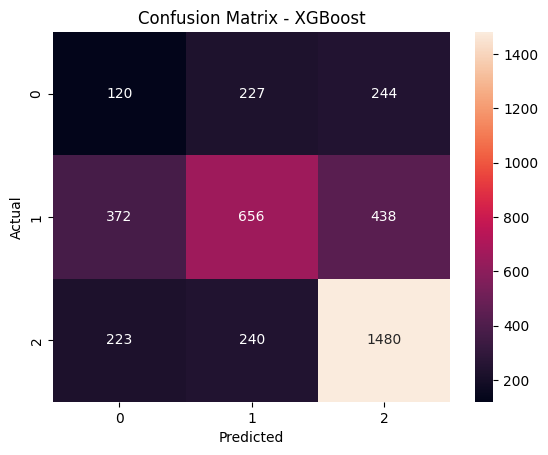

In [49]:
plt.figure()
sns.heatmap(cm_xgb, annot=True, fmt="d")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save Model (LSVM)

In [54]:
import joblib
joblib.dump(pipeline_LSVM, 'priority_model.pkl')

['priority_model.pkl']